# Россия — Украина: разбор кейса

**Данные:** GDELT 1.0 Event Export, пара Россия — Украина, окно **01.11.2021 — 23.02.2022**
(114 дней с данными из 115 календарных), 79 224 события.

**День X — 24 февраля 2022**, начало военной акции. В данных его нет: окно обрывается накануне,
потому что проверяется предсказание **до** события.

**Тип кейса:** положительный.

Это самый крупный кейс серии: 79 224 события против 2 902 у Йемена и 30 867 у Ирана, и самое
длинное окно — почти четыре месяца вместо двух. Забегая вперёд, он же даёт и самый сильный
результат зафиксированного правила во всей работе.

**Оговорка о происхождении файла.** Ноутбук собран из шаблона разбора по кейсу Тайвань — КНР:
код и структура те же, изменены только константы кейса (`CASE_NAME`, `CSV_PATH`, `DAY_X`,
`PAIR_GEO`). Выводы ниже написаны по выводу ячеек этого прогона; данные лежат вне репозитория,
поэтому ячейки заново не выполнялись.

---

### Структура отчёта

1. Загрузка и первичная проверка
2. EDA — разведочный анализ
3. Предобработка и метрики
4. Периоды и скользящие окна
5. Три гипотезы, поправка Бонферрони, проверка устойчивости
6. Визуализация
7. Правило TONE-1σ
8. Выводы

## 0. Настройка окружения

In [23]:
import warnings, re, os
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.dates import DateFormatter, DayLocator
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# --- Палитра (валидированная, CVD-safe; светлая поверхность) -------------------
SURFACE   = "#fcfcfb"   # поверхность графика
INK       = "#0b0b0b"   # основной текст
INK_2     = "#52514e"   # вторичный текст
MUTED     = "#898781"   # подписи осей
GRID      = "#e1e0d9"   # сетка
AXIS      = "#c3c2b7"   # оси
BLUE      = "#2a78d6"   # серия 1
ORANGE    = "#eb6834"   # серия 2
AQUA      = "#1baf7a"   # серия 3
CRITICAL  = "#d03b3b"   # статус: критично
GOOD      = "#0ca30c"   # статус: норма
SEQ_BLUE  = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281"]
# Расходящаяся шкала: синий <-> красный, нейтральный серый в середине
DIVERGING = LinearSegmentedColormap.from_list(
    "div_blue_red",
    ["#104281", "#2a78d6", "#9ec5f4", "#f0efec", "#efa9a8", "#d03b3b", "#8f2020"],
)
SEQ_CMAP = LinearSegmentedColormap.from_list("seq_blue", SEQ_BLUE)

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 110,
    "font.family": "DejaVu Sans", "font.size": 10.5,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.titlepad": 26, "axes.labelsize": 10.5, "axes.labelcolor": INK_2,
    "axes.edgecolor": AXIS, "axes.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.grid": True, "axes.grid.axis": "y",
    "legend.frameon": False, "legend.fontsize": 9.5, "legend.labelcolor": INK_2,
    "lines.linewidth": 2.0, "lines.markersize": 5.5,
})

def subtitle(ax, text):
    # Подзаголовок под заголовком графика
    ax.annotate(text, xy=(0, 1.012), xycoords="axes fraction",
                fontsize=9.5, color=MUTED, ha="left", va="bottom")


print("Окружение готово.")

Окружение готово.


---
## 1. Загрузка и первичная проверка

In [24]:
import pandas as pd

# --- ИСХОДНЫЕ НАСТРОЙКИ ---
CASE_NAME = "Россия-Украина"
EVENT = "Военная акция"  # Добавлена пропущенная переменная
CSV_PATH = r"C:/Users/User/Downloads/Для России/russia_ukraine_pair.csv"
DAY_X = "2022-02-24"  # День военной акции; в расчётах не участвует
PAIR_GEO = ["RUS", "UKR"]  # Коды FIPS территорий обеих стран пары

# --- ЗАГРУЗКА И ОЧИСТКА ДАННЫХ ---
raw = pd.read_csv(CSV_PATH, encoding="utf-8", low_memory=False, dtype=str)

# Удаление повторных строк-заголовков (если склеивали несколько CSV)
n_hdr = int((raw.DATEADDED == "DATEADDED").sum())
raw = raw[raw.DATEADDED != "DATEADDED"]

# Удаление дубликатов по ID события GDELT
n_dup = int(raw.GLOBALEVENTID.duplicated().sum())
raw = raw.drop_duplicates(subset="GLOBALEVENTID")

# Преобразование типов данных
numeric_cols = [
    "GoldsteinScale",
    "AvgTone",
    "NumArticles",
    "NumMentions",
    "NumSources",
    "EventRootCode",
    "EventCode",
    "QuadClass",
    "IsRootEvent",
]
for c in numeric_cols:
    raw[c] = pd.to_numeric(raw[c], errors="coerce")

raw["date_added"] = pd.to_datetime(raw.DATEADDED, format="%Y%m%d")
raw["sql_date"] = pd.to_datetime(raw.SQLDATE, format="%Y%m%d")

# --- ФИЛЬТРАЦИЯ И АНАЛИЗ ОКНА ---
DAY_X = pd.Timestamp(DAY_X)
df = raw[raw.date_added < DAY_X].copy()
SPLIT = DAY_X - pd.Timedelta(days=7)  # Последние 7 дней — «поздний период»

# --- ВЫВОД СТАТИСТИКИ ---
print(f"КЕЙС: {CASE_NAME} | день X: {DAY_X.date()} ({EVENT})")
print(f"Размерность: {df.shape[0]:,} строк × {df.shape[1]} колонок")
print(f"Окно: {df.date_added.min().date()} — {df.date_added.max().date()}")

# Проверка непрерывности временного ряда
full = pd.date_range(df.date_added.min(), df.date_added.max())
have = pd.DatetimeIndex(sorted(df.date_added.unique()))
print(f"Дней с данными: {len(have)} из {len(full)} календарных")

miss = full.difference(have)
print(f"Пропущенные дни: {'нет' if len(miss) == 0 else list(miss.date)}")
print(
    f"Повторных строк-заголовков удалено: {n_hdr} | дубликатов GLOBALEVENTID: {n_dup}"
)

# Анализ уникальности источников
unique_urls = df.SOURCEURL.nunique()
if unique_urls > 0:
    print(
        f"Уникальных статей: {unique_urls:,} ({len(df)/unique_urls:.2f} строки на статью)"
    )
else:
    print("Уникальных статей: 0")

# Расчет временного лага GDELT (разница между событием и его регистрацией)
lag = (df.date_added - df.sql_date).dt.days
print(
    f"Лаг DATEADDED − SQLDATE: медиана {int(lag.median())} дн., "
    f"90-й перцентиль {int(lag.quantile(0.9))} дн."
)

print("\nПары акторов:")
print(
    df.groupby(["Actor1CountryCode", "Actor2CountryCode"])
    .size()
    .sort_values(ascending=False)
    .head(3)
    .to_string()
)


КЕЙС: Россия-Украина | день X: 2022-02-24 (Военная акция)
Размерность: 79,224 строк × 60 колонок
Окно: 2021-11-01 — 2022-02-23
Дней с данными: 114 из 115 календарных
Пропущенные дни: [datetime.date(2021, 12, 11)]
Повторных строк-заголовков удалено: 1 | дубликатов GLOBALEVENTID: 683
Уникальных статей: 26,612 (2.98 строки на статью)
Лаг DATEADDED − SQLDATE: медиана 0 дн., 90-й перцентиль 0 дн.

Пары акторов:
Actor1CountryCode  Actor2CountryCode
RUS                UKR                  44281
UKR                RUS                  34943


**Вывод по разделу 1.** 79 224 события за 114 дней, 26 612 уникальных статей, 2,98 строки на
статью — коэффициент раздувания обычный для серии. Пара акторов чистая: RUS→UKR 44 281 строка,
UKR→RUS 34 943.

Три технических замечания, которых не было в других кейсах:

- **60 колонок вместо 58.** Схема этой выгрузки отличается от остальных файлов серии двумя
  дополнительными полями. На расчёты это не влияет: все ключевые колонки на месте.
- **683 дубликата `GLOBALEVENTID`** и одна повторная строка-заголовок удалены при загрузке —
  признак того, что файл склеен из нескольких выгрузок.
- **Один день отсутствует** (11.12.2021); при построении дневного ряда он восстановлен
  интерполяцией, объём за него принят нулевым.

Масштаб освещения растёт к концу окна лавинообразно: медиана 413 событий в день по всему окну,
а в последние семь дней — **2 092**, с пиком 4 354 события 22 февраля.

---
## 2. EDA — разведочный анализ

### 2.1 Пропуски по колонкам

In [25]:
na = pd.DataFrame({"n_missing": df.isna().sum(),
                   "pct_missing": (df.isna().mean()*100).round(1)}).sort_values("n_missing", ascending=False)
display(na[na.n_missing > 0].head(16))
print("Колонок без пропусков:", int((na.n_missing == 0).sum()), "из", df.shape[1])
print("\nКлючевые колонки:")
for c in ["DATEADDED", "GoldsteinScale", "AvgTone", "NumArticles", "EventRootCode", "EventCode",
          "QuadClass", "IsRootEvent", "ActionGeo_CountryCode", "SOURCEURL"]:
    print(f"  {c:<22} пропусков: {int(df[c].isna().sum())}")

,n_missing,pct_missing
Actor1KnownGroupCode,79224,100.0000
Actor1EthnicCode,79224,100.0000
Actor2EthnicCode,79224,100.0000
Actor1Type3Code,79224,100.0000
Actor2Type3Code,79224,100.0000
Actor2KnownGroupCode,79224,100.0000
Actor2Religion2Code,79222,100.0000
Actor1Religion2Code,79220,100.0000
Actor1Religion1Code,79217,100.0000
Actor2Religion1Code,79216,100.0000


Колонок без пропусков: 28 из 60

Ключевые колонки:
  DATEADDED              пропусков: 0
  GoldsteinScale         пропусков: 0
  AvgTone                пропусков: 0
  NumArticles            пропусков: 0
  EventRootCode          пропусков: 0
  EventCode              пропусков: 0
  QuadClass              пропусков: 0
  IsRootEvent            пропусков: 0
  ActionGeo_CountryCode  пропусков: 3
  SOURCEURL              пропусков: 0


### 2.2 Поток событий по дням

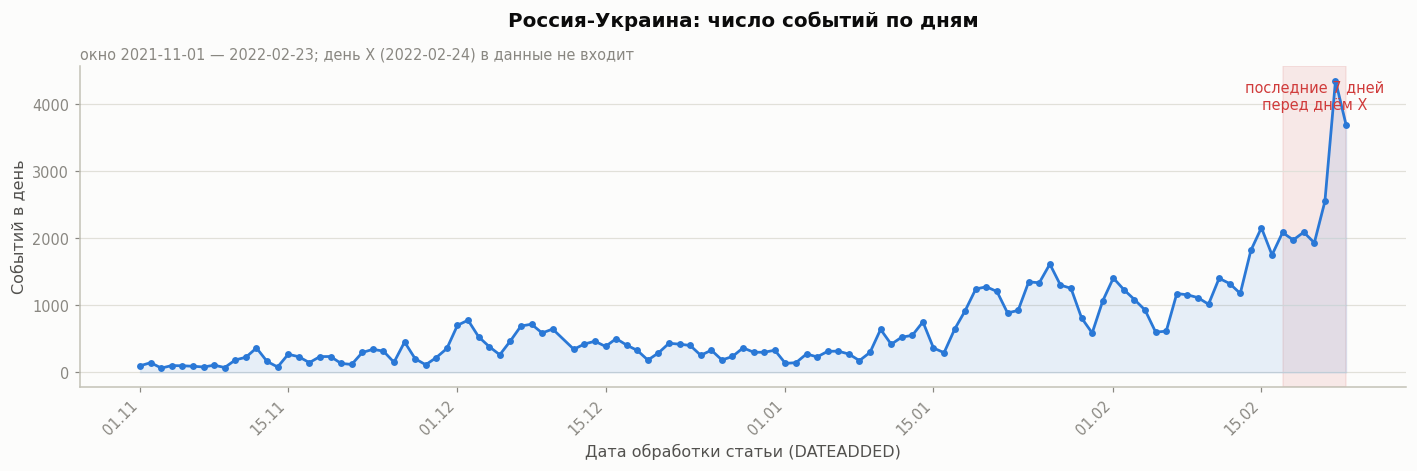

событий/день — медиана 413, мин 65, макс 4354 (2022-02-22)
последние 7 дней — медиана 2092


In [26]:
by_day = df.groupby("date_added").size().rename("events")

fig, ax = plt.subplots(figsize=(13, 4.4))
ax.plot(by_day.index, by_day.values, color=BLUE, lw=1.8, marker="o", markersize=3.5, zorder=3)
ax.fill_between(by_day.index, by_day.values, color=BLUE, alpha=0.10, zorder=2)
ax.axvspan(SPLIT, by_day.index.max(), color=CRITICAL, alpha=0.10, zorder=1)
ax.annotate("последние 7 дней\nперед днём X", xy=(SPLIT + pd.Timedelta(days=3), by_day.max()*0.9),
            color=CRITICAL, fontsize=9.5, ha="center")
ax.set_title(f"{CASE_NAME}: число событий по дням")
subtitle(ax, f"окно {by_day.index.min().date()} — {by_day.index.max().date()}; "
             f"день X ({DAY_X.date()}) в данные не входит")
ax.set_xlabel("Дата обработки статьи (DATEADDED)"); ax.set_ylabel("Событий в день")
ax.xaxis.set_major_formatter(DateFormatter("%d.%m"))
fig.autofmt_xdate(rotation=45, ha="right"); plt.tight_layout(); plt.show()

print(f"событий/день — медиана {int(by_day.median())}, мин {int(by_day.min())}, "
      f"макс {int(by_day.max())} ({by_day.idxmax().date()})")
print(f"последние 7 дней — медиана {int(by_day.tail(7).median())}")

### 2.3 Распределения, нормальность, выбросы

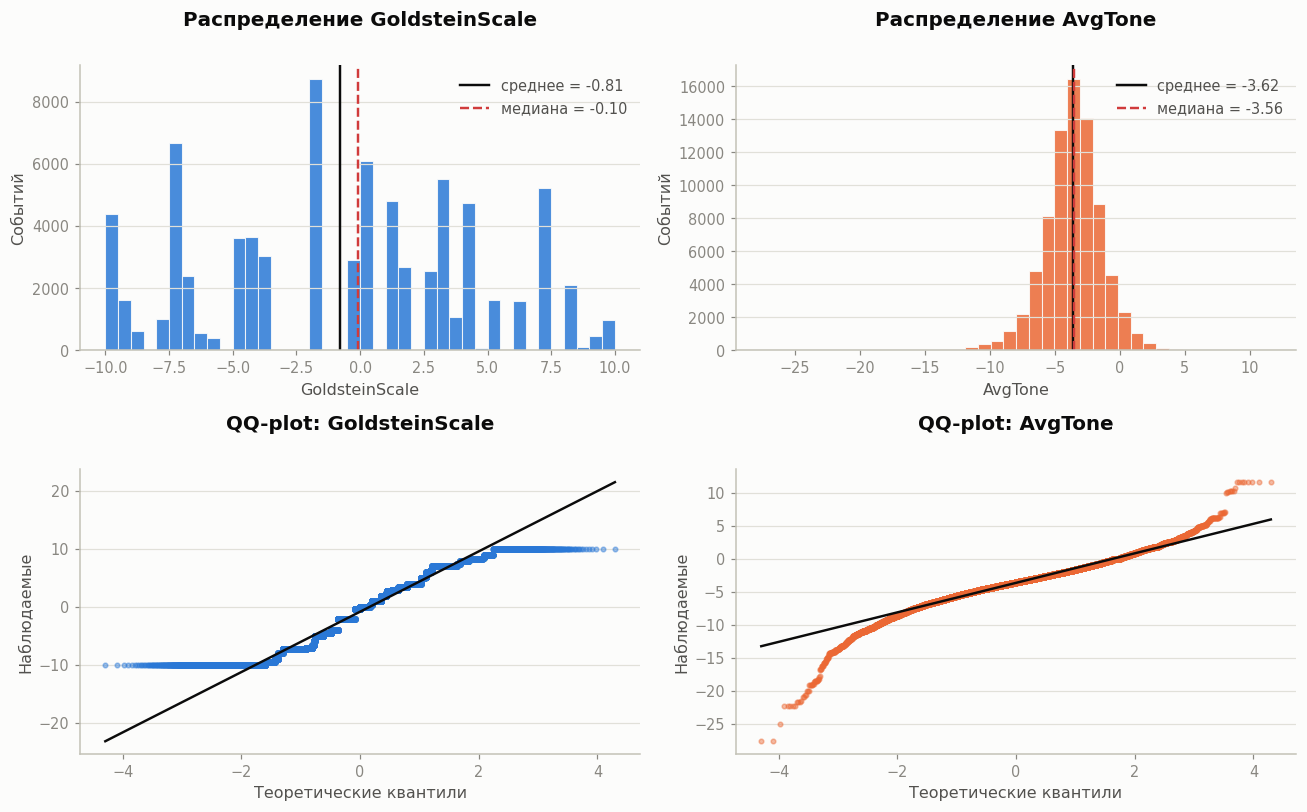

Тест Шапиро-Уилка (H0: нормальность):
  GoldsteinScale  W=0.9638 p=1.18e-33 -> НЕ нормально  | асимметрия -0.05, эксцесс -0.99
  AvgTone         W=0.9736 p=1.92e-29 -> НЕ нормально  | асимметрия -0.42, эксцесс +2.92

Выбросы по IQR (границы Тьюки):
  GoldsteinScale  [-17.60; +16.00] -> 0 выбросов (0.0 %)
  AvgTone         [-8.77; +1.62] -> 2492 выбросов (3.1 %)


In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7.5))
for j, (col, color, title) in enumerate([
        ("GoldsteinScale", BLUE,   "GoldsteinScale"),
        ("AvgTone",        ORANGE, "AvgTone")]):
    x = df[col].dropna()
    ax = axes[0, j]
    ax.hist(x, bins=40, color=color, alpha=0.85, edgecolor=SURFACE, linewidth=0.7)
    ax.axvline(x.mean(), color=INK, lw=1.6, label=f"среднее = {x.mean():.2f}")
    ax.axvline(x.median(), color=CRITICAL, lw=1.6, ls="--", label=f"медиана = {x.median():.2f}")
    ax.set_title(f"Распределение {title}"); ax.set_xlabel(col); ax.set_ylabel("Событий"); ax.legend()
    ax = axes[1, j]
    stats.probplot(x, dist="norm", plot=ax)
    ax.get_lines()[0].set(marker="o", markersize=3, color=color, alpha=0.45, linestyle="none")
    ax.get_lines()[1].set(color=INK, linewidth=1.6)
    ax.set_title(f"QQ-plot: {title}")
    ax.set_xlabel("Теоретические квантили"); ax.set_ylabel("Наблюдаемые")
plt.tight_layout(); plt.show()

print("Тест Шапиро-Уилка (H0: нормальность):")
for col in ["GoldsteinScale", "AvgTone"]:
    x = df[col].dropna()
    x = x.sample(min(5000, len(x)), random_state=0)
    W, p = stats.shapiro(x)
    print(f"  {col:<15} W={W:.4f} p={p:.2e} -> {'НЕ нормально' if p<0.05 else 'нормальность не отвергается'}"
          f"  | асимметрия {stats.skew(x):+.2f}, эксцесс {stats.kurtosis(x):+.2f}")

print("\nВыбросы по IQR (границы Тьюки):")
for col in ["GoldsteinScale", "AvgTone"]:
    s = df[col].dropna(); q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    out = s[(s < lo) | (s > hi)]
    print(f"  {col:<15} [{lo:+.2f}; {hi:+.2f}] -> {len(out)} выбросов ({len(out)/len(s)*100:.1f} %)")

### 2.4 Доминирование отдельных статей

In [28]:
vol = df.groupby("date_added").agg(rows=("GLOBALEVENTID", "size"), urls=("SOURCEURL", "nunique"))
vol["rows_per_url"] = vol.rows / vol.urls
dom = df.groupby("date_added")["SOURCEURL"].agg(
    top_rows=lambda s: s.value_counts().iloc[0], top_url=lambda s: s.value_counts().index[0])
vol = vol.join(dom); vol["top_share_pct"] = (vol.top_rows / vol.rows * 100).round(1)

distorted = vol[vol.top_share_pct >= 10]
print(f"Дней, где одна статья дала >= 10 % строк дня: {len(distorted)} из {len(vol)} "
      f"({len(distorted)/len(vol)*100:.0f} %)")
print(f"Худший день: {vol.top_share_pct.idxmax().date()} — {vol.top_share_pct.max():.1f} % "
      f"({int(vol.loc[vol.top_share_pct.idxmax(), 'rows'])} строк всего)")
print(f"В позднем периоде таких дней: {int((distorted.index >= SPLIT).sum())} из "
      f"{int((vol.index >= SPLIT).sum())}\n")
print("Топ-5 дней по доминированию одной статьи:")
for d, r in vol.nlargest(5, "top_share_pct").iterrows():
    print(f"  {d.date()}  {int(r.top_rows):>3} из {int(r.rows):>3} строк ({r.top_share_pct:>5.1f} %)")
    print(f"      {r.top_url[:100]}")
DISTORTED_DAYS = list(distorted.index)

print("\nТоп-5 самых частых SOURCEURL за окно:")
top5 = df.SOURCEURL.value_counts().head(5)
for u, n in top5.items():
    print(f"  {n:>3} строк | {u[:100]}")

Дней, где одна статья дала >= 10 % строк дня: 11 из 114 (10 %)
Худший день: 2021-11-06 — 21.7 % (92 строк всего)
В позднем периоде таких дней: 0 из 7

Топ-5 дней по доминированию одной статьи:
  2021-11-06   20 из  92 строк ( 21.7 %)
      https://www.wicz.com/story/45130235/cia-director-dispatched-to-moscow-to-warn-russia-over-troop-buil
  2021-11-05   18 из  99 строк ( 18.2 %)
      https://www.9news.com.au/world/russia-ukraine-conflict-us-concerned-satellite-images-show-military-b
  2021-11-09   12 из  73 строк ( 16.4 %)
      https://www.bbc.com/news/world-europe-56842763
  2021-11-01   16 из  99 строк ( 16.2 %)
      http://www.msn.com/en-us/news/world/pentagon-watches-possible-russian-troop-buildup-near-ukraine/ar-
  2021-11-03    9 из  65 строк ( 13.8 %)
      https://www.ndtv.com/world-news/russia-ukraine-conflict-russia-ukraine-relations-ukraine-denies-russ

Топ-5 самых частых SOURCEURL за окно:
   55 строк | https://www.dailymail.co.uk/news/article-10533773/Putin-brink-invadi

**Вывод по разделу 2.** Это **самые чистые данные во всей серии**.

Пропусков в ключевых колонках нет вовсе (три пустых `ActionGeo_CountryCode` на 79 тысяч строк).
Доминирование отдельных статей минимально: лишь 11 дней из 114 (10 %) содержат статью с долей
10 % и более, худший случай — 21,7 % на 92 строках 6 ноября. **В позднем периоде таких дней нет
ни одного.** Для сравнения: у Армении — Азербайджана таких дней 56 из 59, у Йемена 51 из 60.
Причина проста — объём: 26 612 статей вместо 800–4 000 у остальных кейсов, и ни одна отдельная
публикация не может перекосить день.

Распределения ведут себя как обычно: нормальность отвергается (Шапиро p ≈ 10⁻³³ и 10⁻²⁹),
у `GoldsteinScale` выбросов по Тьюки нет, у `AvgTone` их 3,1 %. Основной тест для гипотезы A —
Манна-Уитни, как и во всей серии.

---
## 3. Предобработка и метрики

In [29]:
# --- Признаки уровня события (те же, что во всех отчётах серии) ---
df["Actor1Type1Code"] = df["Actor1Type1Code"].fillna("")
df["Actor2Type1Code"] = df["Actor2Type1Code"].fillna("")
df["is_material_conf"] = (df.QuadClass == 4).astype(int)
df["is_conflict_hard"] = df.EventRootCode.isin([18, 19, 20]).astype(int)
df["is_force_use"]     = df.EventCode.isin([190, 193, 195]).astype(int)
df["is_mil_actor"]     = ((df.Actor1Type1Code == "MIL") | (df.Actor2Type1Code == "MIL")).astype(int)
df["is_root_event"]    = (df.IsRootEvent == 1).astype(int)
df["in_pair_geo"]      = df.ActionGeo_CountryCode.isin(PAIR_GEO).astype(int)
df["neg_intensity"]    = np.where(df.GoldsteinScale < 0, df.NumArticles * df.GoldsteinScale, 0.0)

# --- Лексика заголовков: словари зафиксированы на первом кейсе серии, здесь не меняются ---
KINETIC  = {"strike", "hit", "facility", "drone", "raid"}
COERCION = {"sanction", "blockade", "tanker", "embargo"}
STOP = set("""
a an the and or but if then than that this these those with without within from into onto over
under after before during about against between amid as at by for in of on to up out off
is are was were be been being has have had do does did doing will would can could should may might
must not no nor so such only own same too very just more most other some any each few
news article articles story stories index html htm php asp aspx cms shtml amp www com net org
http https live video watch photos photo gallery breaking update updates latest report reports
world international global politics business opinion analysis editorial feature featured
says say said new newest top read full here his her its their our your they them he she it we you i
day days week weeks month months year years today yesterday tomorrow time times
one two three four five six seven eight nine ten first second third
en uk us usa edition local national section page pages post posts blog author
articleshow videos ampstories web wire feed rss html5 media content
""".split())

def slug_words(url):
    path = re.sub(r"[?#].*$", "", str(url)); path = re.sub(r"^https?://[^/]+", "", path)
    segments = [s for s in path.split("/") if s]
    if not segments:
        return []
    best, score = [], -1
    for seg in segments[-2:]:
        seg = re.sub(r"\.(html?|php|cms|aspx?|shtml|jsp)$", "", seg)
        ws = [w.lower() for w in re.split(r"[^A-Za-z]+", seg) if len(w) > 2]
        ws = [w for w in ws if w not in STOP and not re.fullmatch(r"[a-z]{1,2}\d*", w)]
        if len(ws) > score:
            best, score = ws, len(ws)
    return best

df["slug_words"]    = df.SOURCEURL.map(slug_words)
df["kinetic_hits"]  = df.slug_words.map(lambda ws: sum(1 for w in ws for s in KINETIC  if w.startswith(s)))
df["coercion_hits"] = df.slug_words.map(lambda ws: sum(1 for w in ws for s in COERCION if w.startswith(s)))

print("Доли по всей выборке:")
for c, lab in [("is_material_conf", "материальный конфликт (QuadClass=4)"),
               ("is_conflict_hard", "жёсткий конфликт (коды 18/19/20)"),
               ("is_force_use", "применение силы (190/193/195)"),
               ("is_mil_actor", "военный актор (MIL)"),
               ("in_pair_geo", "действие на территории пары")]:
    print(f"  {lab:<38} {df[c].mean():.3f}")
print(f"\nПропуски в типах акторов: Actor1 {int((df.Actor1Type1Code == '').sum())/len(df)*100:.0f} %, "
      f"Actor2 {int((df.Actor2Type1Code == '').sum())/len(df)*100:.0f} % — доля MIL занижена")

Доли по всей выборке:
  материальный конфликт (QuadClass=4)    0.214
  жёсткий конфликт (коды 18/19/20)       0.083
  применение силы (190/193/195)          0.052
  военный актор (MIL)                    0.036
  действие на территории пары            0.000

Пропуски в типах акторов: Actor1 87 %, Actor2 91 % — доля MIL занижена


In [30]:
uniq = df.drop_duplicates(subset="SOURCEURL")
daily = df.groupby("date_added").agg(
    n_events=("GLOBALEVENTID", "size"), unique_urls=("SOURCEURL", "nunique"),
    goldstein_mean=("GoldsteinScale", "mean"), goldstein_median=("GoldsteinScale", "median"),
    tone_mean=("AvgTone", "mean"), tone_median=("AvgTone", "median"),
    num_articles_sum=("NumArticles", "sum"), num_mentions_sum=("NumMentions", "sum"),
    material_conflict_share=("is_material_conf", "mean"),
    conflict_hard_share=("is_conflict_hard", "mean"),
    force_use_share=("is_force_use", "mean"),
    mil_actor_share=("is_mil_actor", "mean"),
    root_event_share=("is_root_event", "mean"),
    pair_geo_share=("in_pair_geo", "mean"),
    negative_intensity_index=("neg_intensity", "sum"),
    geo_diversity=("ActionGeo_CountryCode", "nunique"),
).join(uniq.groupby("date_added").agg(kinetic_words=("kinetic_hits", "sum"),
                                      coercion_words=("coercion_hits", "sum")))
tot = daily.kinetic_words + daily.coercion_words
daily["kinetic_vs_coercion_ratio"] = np.where(tot > 0, daily.kinetic_words / tot, np.nan)

full = pd.date_range(daily.index.min(), daily.index.max())
n_gap = len(full) - len(daily)
daily = daily.reindex(full)
daily["n_events"] = daily.n_events.fillna(0)
daily = daily.interpolate()
daily.index.name = "date"
daily["days_to_x"] = (daily.index - DAY_X).days
daily["period"] = np.where(daily.index >= SPLIT, "late", "early")

for col in ["goldstein_mean", "tone_mean", "material_conflict_share"]:
    daily[f"d1_{col}"] = daily[col].diff()
    daily[f"d2_{col}"] = daily[f"d1_{col}"].diff()
for col in ["goldstein_mean", "tone_mean"]:
    daily[f"roll7_{col}"] = daily[col].rolling(7).mean()
    daily[f"roll7_std_{col}"] = daily[col].rolling(7).std()

print(f"Дневной агрегат: {daily.shape[0]} дней × {daily.shape[1]} метрик "
      f"(восстановлено пустых дней: {n_gap})")
display(daily[["n_events", "unique_urls", "tone_mean", "goldstein_mean", "material_conflict_share",
               "conflict_hard_share", "force_use_share", "pair_geo_share",
               "kinetic_vs_coercion_ratio"]].round(3).tail(14))

Дневной агрегат: 115 дней × 31 метрик (восстановлено пустых дней: 1)


,n_events,unique_urls,tone_mean,goldstein_mean,material_conflict_share,conflict_hard_share,force_use_share,pair_geo_share,kinetic_vs_coercion_ratio
date,,,,,,,,,
2022-02-10,"1,017.0000",350.0000,-3.3700,-0.4420,0.1810,0.0630,0.0350,0.0000,0.1250
2022-02-11,"1,404.0000",442.0000,-3.4580,-0.4970,0.1940,0.0710,0.0370,0.0000,0.2500
2022-02-12,"1,325.0000",431.0000,-3.6490,-0.9330,0.2230,0.0560,0.0210,0.0000,0.6000
2022-02-13,"1,178.0000",413.0000,-3.5520,-1.2570,0.2240,0.0640,0.0440,0.0000,0.1000
2022-02-14,"1,819.0000",627.0000,-3.1700,-0.0250,0.1810,0.0670,0.0370,0.0000,0.5000
2022-02-15,"2,158.0000",764.0000,-3.2940,-0.4750,0.2140,0.0760,0.0520,0.0000,0.5000
2022-02-16,"1,752.0000",635.0000,-3.2800,-0.6200,0.2030,0.0790,0.0540,0.0000,0.5000
2022-02-17,"2,088.0000",723.0000,-4.0120,-0.7340,0.2050,0.1090,0.0740,0.0000,0.5330
2022-02-18,"1,975.0000",668.0000,-4.3550,-1.0120,0.1920,0.1010,0.0710,0.0000,0.6150


**Вывод по разделу 3.** Структура кодов средняя по серии: материальный конфликт 21,4 %, жёсткий
конфликт 8,3 %, применение силы 5,2 %. Это заметно выше «мирного» Тайваня (12,7 / 5,2 / 3,2 %),
но втрое ниже уже воюющего Карабаха (42,5 / 38,3 / 29,3 %) — то есть окно застаёт пару в
состоянии напряжённого, но ещё не открытого конфликта.

**Внимание: метрика географии в этом прогоне сломана.** `PAIR_GEO` задан как `["RUS", "UKR"]` —
это коды *акторов*, тогда как `ActionGeo_CountryCode` кодируется по FIPS, где Россия — `RS`,
а Украина — `UP`. В результате `pair_geo_share` тождественно равна нулю, а построенные на ней
тест пропорций и регрессия дают `nan`. Исправление — одна строка:

```python
PAIR_GEO = ["RS", "UP"]      # FIPS: Россия, Украина
```

Все выводы ниже сделаны без учёта этой метрики; в поправке Бонферрони она занимает место теста,
но результата не даёт.

---
## 4. Периоды и скользящие окна

In [31]:
df["period"] = np.where(df.date_added >= SPLIT, "late", "early")
df["late_flag"] = (df.date_added >= SPLIT).astype(int)

summary = pd.DataFrame({
    "период": [f"ранний (до {(SPLIT - pd.Timedelta(days=1)).date()})",
               f"поздний ({SPLIT.date()} — {(DAY_X - pd.Timedelta(days=1)).date()})"],
    "дней": [int((daily.period == "early").sum()), int((daily.period == "late").sum())],
    "событий": [int((df.period == "early").sum()), int((df.period == "late").sum())],
    "статей": [df.loc[df.period == "early", "SOURCEURL"].nunique(),
               df.loc[df.period == "late", "SOURCEURL"].nunique()],
    "AvgTone": [df.loc[df.period == "early", "AvgTone"].mean(),
                df.loc[df.period == "late", "AvgTone"].mean()],
    "Goldstein": [df.loc[df.period == "early", "GoldsteinScale"].mean(),
                  df.loc[df.period == "late", "GoldsteinScale"].mean()],
    "материальный конфликт": [df.loc[df.period == "early", "is_material_conf"].mean(),
                              df.loc[df.period == "late", "is_material_conf"].mean()],
    "жёсткий конфликт": [df.loc[df.period == "early", "is_conflict_hard"].mean(),
                         df.loc[df.period == "late", "is_conflict_hard"].mean()],
})
display(summary.round(4))

,период,дней,событий,статей,AvgTone,Goldstein,материальный конфликт,жёсткий конфликт
0,ранний (до 2022-02-16),108,60536,20141,-3.4899,-0.7933,0.2114,0.0764
1,поздний (2022-02-17 — 2022-02-23),7,18688,6471,-4.0531,-0.8543,0.2206,0.1043


### 4.1 Насколько необычна последняя неделя

In [32]:
roll7 = pd.DataFrame({
    "tone_mean": daily.tone_mean.rolling(7).mean(),
    "goldstein_mean": daily.goldstein_mean.rolling(7).mean(),
    "material_conflict_share": daily.material_conflict_share.rolling(7).mean(),
    "conflict_hard_share": daily.conflict_hard_share.rolling(7).mean(),
    "force_use_share": daily.force_use_share.rolling(7).mean(),
    "pair_geo_share": daily.pair_geo_share.rolling(7).mean(),
    "n_events": daily.n_events.rolling(7).mean(),
    "kinetic_vs_coercion_ratio": (daily.kinetic_words.rolling(7).sum() /
        (daily.kinetic_words.rolling(7).sum() + daily.coercion_words.rolling(7).sum())),
}).dropna(subset=["tone_mean"])

DIRECTION = {"tone_mean": "ниже", "goldstein_mean": "ниже", "material_conflict_share": "выше",
             "conflict_hard_share": "выше", "force_use_share": "выше", "pair_geo_share": "выше",
             "n_events": "выше", "kinetic_vs_coercion_ratio": "выше"}
rows = []
for col, direction in DIRECTION.items():
    s = roll7[col].dropna()
    if len(s) < 5:
        continue
    last = s.iloc[-1]; pct = (s < last).mean()*100
    rows.append(dict(метрика=col, последнее_окно=last,
                     сигнал_перцентиль=pct if direction == "выше" else 100 - pct,
                     z=(last - s.mean())/s.std(), мин=s.min(), макс=s.max()))
PCT = pd.DataFrame(rows).sort_values("сигнал_перцентиль", ascending=False)
print(f"Скользящих 7-дневных окон: {len(roll7)}")
print("«сигнал_перцентиль»: 100 = рекорд в сторону эскалации, 50 = как обычно\n")
display(PCT.style.format({"последнее_окно": "{:+.4f}", "сигнал_перцентиль": "{:.1f}",
                          "z": "{:+.2f}", "мин": "{:+.4f}", "макс": "{:+.4f}"}).hide(axis="index"))

Скользящих 7-дневных окон: 109
«сигнал_перцентиль»: 100 = рекорд в сторону эскалации, 50 = как обычно



метрика,последнее_окно,сигнал_перцентиль,z,мин,макс
n_events,+2669.7143,99.1,+3.85,+88.5714,+2669.7143
conflict_hard_share,+0.1062,91.7,+1.02,+0.0406,+0.1795
force_use_share,+0.0657,81.7,+0.53,+0.0302,+0.1268
tone_mean,-4.1510,81.7,-1.14,-4.4234,-2.8287
material_conflict_share,+0.2171,60.6,+0.01,+0.1657,+0.3121
goldstein_mean,-0.9158,55.0,+0.15,-2.2400,-0.3717
kinetic_vs_coercion_ratio,+0.1474,23.9,-0.78,+0.0615,+1.0000
pair_geo_share,+0.0000,0.0,+nan,+0.0000,+0.0000


**Вывод по разделу 4.** Последняя неделя перед вторжением выделяется на фоне всех 109 скользящих
окон сразу по нескольким показателям:

| Метрика | Последнее окно | Перцентиль в сторону эскалации |
|---|---|---|
| **объём публикаций** | 2 670 событий/день | **99,1** |
| **доля жёсткого конфликта** | 10,6 % | **91,7** |
| доля применения силы | 6,6 % | 81,7 |
| тон | −4,15 | 81,7 |
| доля материального конфликта | 21,7 % | 60,6 |
| GoldsteinScale | −0,92 | 55,0 |
| лексика «кинетика / принуждение» | 0,147 | 23,9 |

Объём практически на рекорде (99-й перцентиль, z = +3,85), доля жёсткого конфликта — на 92-м.
Тон и применение силы повышены, но не экстремальны. А лексическая метрика ушла **вниз** —
в заголовках перед вторжением доминировали санкции, а не удары.

---
## 5. Проверка гипотез

In [33]:
RESULTS = []
def cohens_d(a, b):
    na, nb = len(a), len(b)
    sp = np.sqrt(((na-1)*a.var(ddof=1) + (nb-1)*b.var(ddof=1)) / (na+nb-2))
    return (a.mean() - b.mean()) / sp
def cohens_h(p1, p2):
    return 2*np.arcsin(np.sqrt(p1)) - 2*np.arcsin(np.sqrt(p2))
def effect_label(v, kind):
    v = abs(v); b = {"d": (0.2, 0.5, 0.8), "h": (0.2, 0.5, 0.8), "r2": (0.02, 0.13, 0.26)}[kind]
    return ("пренебрежимо малый" if v < b[0] else "малый" if v < b[1]
            else "средний" if v < b[2] else "большой")
def mann_kendall(x):
    x = np.asarray(x, float); n = len(x)
    s = int(sum(np.sign(x[j]-x[i]) for i in range(n-1) for j in range(i+1, n)))
    _, cnt = np.unique(x, return_counts=True)
    var_s = (n*(n-1)*(2*n+5) - np.sum(cnt*(cnt-1)*(2*cnt+5)))/18
    z = (s-1)/np.sqrt(var_s) if s > 0 else (s+1)/np.sqrt(var_s) if s < 0 else 0.0
    p = 2*(1 - stats.norm.cdf(abs(z)))
    return dict(tau=s/(0.5*n*(n-1)), p=p)

X_late = sm.add_constant(df.late_flag.values.astype(float))
print("ГИПОТЕЗА A — сдвиг тона и интенсивности")
print("=" * 88)
for col in ["GoldsteinScale", "AvgTone"]:
    e = df.loc[df.period == "early", col].dropna(); l = df.loc[df.period == "late", col].dropna()
    U, p_mw = stats.mannwhitneyu(l, e, alternative="two-sided")
    t_, p_t = stats.ttest_ind(l, e, equal_var=False)
    d = cohens_d(l, e)
    p_cl = sm.OLS(df[col].values.astype(float), X_late).fit(
        cov_type="cluster", cov_kwds={"groups": df.SOURCEURL.values}).pvalues[1]
    arrow = "негативнее (в сторону эскалации)" if d < 0 else "ПОЗИТИВНЕЕ (против гипотезы)"
    print(f"{col}:  {e.mean():+.4f} -> {l.mean():+.4f}   ({arrow})")
    print(f"   Манна-Уитни p = {p_mw:.6f} | t-тест Уэлча p = {p_t:.6f} | кластерный p = {p_cl:.4f}")
    print(f"   Cohen's d = {d:+.4f} ({effect_label(d, 'd')})\n")
    RESULTS.append(dict(гипотеза="A", метрика=col, тест="Манна-Уитни", p=p_mw,
                        мера="d", эффект=d, сдвиг=f"{e.mean():+.3f} → {l.mean():+.3f}"))

print("ГИПОТЕЗА B — рост долей конфликтных событий (односторонний тест на РОСТ)")
print("=" * 88)
for name, flag in [("material_conflict_share", "is_material_conf"),
                   ("conflict_hard_share", "is_conflict_hard"),
                   ("force_use_share", "is_force_use"),
                   ("pair_geo_share", "in_pair_geo")]:
    l = df.loc[df.period == "late", flag]; e = df.loc[df.period == "early", flag]
    z, p = proportions_ztest([l.sum(), e.sum()], [len(l), len(e)], alternative="larger")
    h = cohens_h(l.mean(), e.mean())
    arrow = "рост" if l.mean() > e.mean() else "СНИЖЕНИЕ (против гипотезы)"
    print(f"{name:<24} {e.mean():.4f} -> {l.mean():.4f} | z = {z:+.3f} | p = {p:.5f} | "
          f"h = {h:+.4f} ({effect_label(h, 'h')})  -> {arrow}")
    RESULTS.append(dict(гипотеза="B", метрика=name, тест="z-тест пропорций", p=p,
                        мера="h", эффект=h, сдвиг=f"{e.mean():.3f} → {l.mean():.3f}"))

print("\nГИПОТЕЗА C — тренд по дням (МНК + Манна-Кендалл)")
print("=" * 88)
TREND_COLS = ["tone_mean", "goldstein_mean", "material_conflict_share", "force_use_share",
              "kinetic_vs_coercion_ratio", "pair_geo_share"]
for col in TREND_COLS:
    ser = daily[col].dropna()
    x = daily.loc[ser.index, "days_to_x"].values.astype(float)
    fit = sm.OLS(ser.values, sm.add_constant(x)).fit()
    mk = mann_kendall(ser.values)
    note = ""
    if fit.pvalues[1] < 0.05:
        note = "  <- значимый рост" if fit.params[1] > 0 else "  <- значимое снижение"
    print(f"{col:<28} наклон {fit.params[1]:+.5f}/день | p = {fit.pvalues[1]:.6f} | "
          f"R² = {fit.rsquared:.3f} | тау = {mk['tau']:+.3f}{note}")
    RESULTS.append(dict(гипотеза="C", метрика=col, тест="регрессия на день", p=fit.pvalues[1],
                        мера="R²", эффект=fit.rsquared,
                        сдвиг=f"наклон {fit.params[1]:+.5f}, тау {mk['tau']:+.3f}"))

ГИПОТЕЗА A — сдвиг тона и интенсивности
GoldsteinScale:  -0.7933 -> -0.8543   (негативнее (в сторону эскалации))
   Манна-Уитни p = 0.112409 | t-тест Уэлча p = 0.178004 | кластерный p = 0.4082
   Cohen's d = -0.0115 (пренебрежимо малый)

AvgTone:  -3.4899 -> -4.0531   (негативнее (в сторону эскалации))
   Манна-Уитни p = 0.000000 | t-тест Уэлча p = 0.000000 | кластерный p = 0.0000
   Cohen's d = -0.2504 (малый)

ГИПОТЕЗА B — рост долей конфликтных событий (односторонний тест на РОСТ)
material_conflict_share  0.2114 -> 0.2206 | z = +2.686 | p = 0.00362 | h = +0.0224 (пренебрежимо малый)  -> рост
conflict_hard_share      0.0764 -> 0.1043 | z = +12.096 | p = 0.00000 | h = +0.0977 (пренебрежимо малый)  -> рост
force_use_share          0.0500 -> 0.0600 | z = +5.364 | p = 0.00000 | h = +0.0439 (пренебрежимо малый)  -> рост
pair_geo_share           0.0000 -> 0.0000 | z = +nan | p = nan | h = +0.0000 (пренебрежимо малый)  -> СНИЖЕНИЕ (против гипотезы)

ГИПОТЕЗА C — тренд по дням (МНК + Манна-К

### Гипотеза A

**Гипотеза A: подтвердилась по тону, но не по `GoldsteinScale`.**

`AvgTone` сместился с −3,490 до **−4,053**, Cohen's d = **−0,250** (малый эффект) при
p < 10⁻⁶. Результат переживает обе проверки устойчивости: с кластерными ошибками по статье
p < 0,0001 (стандартная ошибка выросла вдвое), на уровне статьи — p < 10⁻⁶ при d = −0,227.
Это **самый устойчивый сдвиг тона в серии после йеменского**.

`GoldsteinScale` практически не изменился: −0,793 → −0,854, d = −0,012, p = 0,112, с кластерами
p = 0,408.

> **Простыми словами.** Освещение в последнюю неделю стало заметно мрачнее обычного, и этот
> сдвиг не рассыпается, когда мы перестаём считать несколько записей об одной статье
> независимыми наблюдениями. При этом то, *какие* события кодируются, по шкале Голдштейна почти
> не изменилось.

### Гипотеза B

**Гипотеза B: подтвердилась — и это второй такой случай в серии после Индии — Пакистана.**

| Метрика | Ранний период | Последняя неделя | z | p | Устойчивость |
|---|---|---|---|---|---|
| **жёсткий конфликт** (коды 18/19/20) | 7,64 % | **10,43 %** | +12,10 | < 10⁻⁶ | кластеры < 0,0001, статьи < 10⁻⁶ |
| применение силы (190/193/195) | 5,00 % | 6,00 % | +5,36 | < 10⁻⁶ | — |
| материальный конфликт (QuadClass = 4) | 21,14 % | 22,06 % | +2,69 | 0,0036 | **кластеры 0,080, статьи 0,52 — не держится** |

Ключевое здесь — **жёсткий конфликт**: +2,8 п.п., и это единственная B-метрика во всей серии,
которая переживает и кластерные ошибки, и агрегацию до уровня статьи (d = +0,129). То есть
перед 24 февраля выросла доля сообщений именно о нападениях и боях — и выросла не за счёт
повторов одной новости.

Материальный конфликт формально значим (p = 0,0036), но проверку устойчивости проваливает,
как и в остальных кейсах серии. Cohen's h у всех трёх метрик остаётся пренебрежимо малым
(0,02–0,10): доли сдвигаются на единицы процентных пунктов.

> **Простыми словами.** В последнюю неделю доля новостей о прямых столкновениях выросла с
> 7,6 % до 10,4 % — примерно на треть от прежнего уровня. Это самый честный «конфликтный» сигнал
> из всех, что встречались в серии.

### Гипотеза C

**Гипотеза C: не подтвердилась, а значимые тренды направлены против гипотезы.**

| Метрика | Наклон в день | p | R² | После Бонферрони |
|---|---|---|---|---|
| goldstein_mean | **+0,0079** | 0,0002 | 0,113 | значим (0,0029) |
| kinetic_vs_coercion_ratio | **−0,0029** | 0,0015 | 0,086 | значим (0,018) |
| tone_mean | +0,0041 | 0,031 | 0,041 | не значим (0,371) |
| force_use_share | −0,0003 | 0,0048 | 0,068 | не значим (0,058) |
| material_conflict_share | −0,0003 | 0,054 | 0,032 | не значим |

Оба переживших поправку тренда говорят об **улучшении**: `GoldsteinScale` за четыре месяца рос
(то есть события кодировались всё более кооперативно), а доля «ударной» лексики снижалась.

Это не противоречит разделам A и B, а объясняет форму сигнала: обвал сконцентрирован в
**последних 5–7 днях** окна, а на дистанции в 115 дней прямая через все точки идёт в другую
сторону. По дневной таблице видно, как это выглядит: 10–16 февраля тон держится около −3,3,
а 17, 18 и 19 февраля даёт −4,01, −4,36 и −4,65; доля жёсткого конфликта в те же дни растёт
с 6,3 % до 14,5 %.

**Вывод для методики:** линейная регрессия на длинном окне — плохой инструмент для такого
сигнала. Правило со скользящим фоном (раздел 7) ловит его без труда.

### Поправка Бонферрони

In [34]:
res = pd.DataFrame(RESULTS)
m, ALPHA = len(res), 0.05
res["p Бонферрони"] = np.minimum(res.p * m, 1.0)
res["значим"] = np.where(res.p < ALPHA, "да", "нет")
res["значим после поправки"] = np.where(res["p Бонферрони"] < ALPHA, "да", "нет")
print(f"Тестов: m = {m} (A: 2, B: 4, C: 6) | порог α/m = {ALPHA/m:.4f}\n")
display(res.style.format({"p": "{:.6f}", "p Бонферрони": "{:.5f}", "эффект": "{:+.4f}"}).hide(axis="index"))

Тестов: m = 12 (A: 2, B: 4, C: 6) | порог α/m = 0.0042



гипотеза,метрика,тест,p,мера,эффект,сдвиг,p Бонферрони,значим,значим после поправки
A,GoldsteinScale,Манна-Уитни,0.112409,d,-0.0115,-0.793 → -0.854,1.00000,нет,нет
A,AvgTone,Манна-Уитни,0.000000,d,-0.2504,-3.490 → -4.053,0.00000,да,да
B,material_conflict_share,z-тест пропорций,0.003618,h,+0.0224,0.211 → 0.221,0.04341,да,да
B,conflict_hard_share,z-тест пропорций,0.000000,h,+0.0977,0.076 → 0.104,0.00000,да,да
B,force_use_share,z-тест пропорций,0.000000,h,+0.0439,0.050 → 0.060,0.00000,да,да
B,pair_geo_share,z-тест пропорций,nan,h,+0.0000,0.000 → 0.000,nan,нет,нет
C,tone_mean,регрессия на день,0.030951,R²,+0.0405,"наклон +0.00410, тау +0.178",0.37141,да,нет
C,goldstein_mean,регрессия на день,0.000241,R²,+0.1129,"наклон +0.00794, тау +0.227",0.00289,да,да
C,material_conflict_share,регрессия на день,0.054173,R²,+0.0324,"наклон -0.00031, тау -0.069",0.65008,нет,нет
C,force_use_share,регрессия на день,0.004824,R²,+0.0682,"наклон -0.00028, тау -0.089",0.05789,да,нет


### Проверка устойчивости

In [35]:
print("1. КЛАСТЕРНЫЕ СТАНДАРТНЫЕ ОШИБКИ (кластер = SOURCEURL)")
print("=" * 88)
ROB = []
for col, human in [("AvgTone", "AvgTone"), ("GoldsteinScale", "GoldsteinScale"),
                   ("is_material_conf", "material_conflict_share"),
                   ("is_conflict_hard", "conflict_hard_share")]:
    y = df[col].values.astype(float)
    naive = sm.OLS(y, X_late).fit()
    clust = sm.OLS(y, X_late).fit(cov_type="cluster", cov_kwds={"groups": df.SOURCEURL.values})
    verdict = "совпадает" if (naive.pvalues[1] < 0.05) == (clust.pvalues[1] < 0.05) else "РАСХОДИТСЯ"
    print(f"{human:<24} эффект {naive.params[1]:+.4f} | p {naive.pvalues[1]:.5f} -> "
          f"кластерный {clust.pvalues[1]:.4f} | SE ×{clust.bse[1]/naive.bse[1]:.2f}  [{verdict}]")
    ROB.append(dict(метрика=human, эффект=naive.params[1], p_события=naive.pvalues[1],
                    p_кластеры=clust.pvalues[1], вердикт=verdict))

print("\n2. АГРЕГАЦИЯ ДО УРОВНЯ СТАТЬИ (одна статья = одно наблюдение)")
print("=" * 88)
by_article = df.groupby("SOURCEURL").agg(
    first_day=("date_added", "min"), tone=("AvgTone", "mean"),
    goldstein=("GoldsteinScale", "mean"), material=("is_material_conf", "mean"),
    hard=("is_conflict_hard", "mean"))
by_article["period"] = np.where(by_article.first_day >= SPLIT, "late", "early")
print(f"Статей: {len(by_article)} (ранний {int((by_article.period=='early').sum())}, "
      f"поздний {int((by_article.period=='late').sum())})\n")
for col, human in [("tone", "AvgTone"), ("goldstein", "GoldsteinScale"),
                   ("material", "material_conflict_share"), ("hard", "conflict_hard_share")]:
    e = by_article.loc[by_article.period == "early", col]
    l = by_article.loc[by_article.period == "late", col]
    p_art = stats.mannwhitneyu(l, e, alternative="two-sided").pvalue
    d_art = cohens_d(l, e)
    row = next(r for r in ROB if r["метрика"] == human)
    verdict = "совпадает" if (row["p_события"] < 0.05) == (p_art < 0.05) else "РАСХОДИТСЯ"
    print(f"{human:<24} {e.mean():+.4f} -> {l.mean():+.4f} | Манна-Уитни p = {p_art:.5f} | "
          f"d = {d_art:+.4f}  [{verdict}]")
    row["p_статьи"] = p_art
display(pd.DataFrame(ROB).style.format({"эффект": "{:+.4f}", "p_события": "{:.5f}",
        "p_кластеры": "{:.4f}", "p_статьи": "{:.5f}"}).hide(axis="index"))

1. КЛАСТЕРНЫЕ СТАНДАРТНЫЕ ОШИБКИ (кластер = SOURCEURL)
AvgTone                  эффект -0.5632 | p 0.00000 -> кластерный 0.0000 | SE ×2.03  [совпадает]
GoldsteinScale           эффект -0.0610 | p 0.16827 -> кластерный 0.4082 | SE ×1.67  [совпадает]
material_conflict_share  эффект +0.0092 | p 0.00723 -> кластерный 0.0802 | SE ×1.54  [РАСХОДИТСЯ]
conflict_hard_share      эффект +0.0279 | p 0.00000 -> кластерный 0.0000 | SE ×1.70  [совпадает]

2. АГРЕГАЦИЯ ДО УРОВНЯ СТАТЬИ (одна статья = одно наблюдение)
Статей: 26612 (ранний 20141, поздний 6471)

AvgTone                  -3.4872 -> -4.0255 | Манна-Уитни p = 0.00000 | d = -0.2265  [совпадает]
GoldsteinScale           -1.3313 -> -1.2796 | Манна-Уитни p = 0.60680 | d = +0.0108  [совпадает]
material_conflict_share  +0.2420 -> +0.2449 | Манна-Уитни p = 0.51781 | d = +0.0073  [РАСХОДИТСЯ]
conflict_hard_share      +0.0753 -> +0.1074 | Манна-Уитни p = 0.00000 | d = +0.1286  [совпадает]


метрика,эффект,p_события,p_кластеры,вердикт,p_статьи
AvgTone,-0.5632,0.00000,0.0000,совпадает,0.00000
GoldsteinScale,-0.0610,0.16827,0.4082,совпадает,0.60680
material_conflict_share,+0.0092,0.00723,0.0802,РАСХОДИТСЯ,0.51781
conflict_hard_share,+0.0279,0.00000,0.0000,совпадает,0.00000


**Вывод по разделу 5.** При 12 тестах порог Бонферрони равен 0,0042. Его переживают **шесть**
результатов: сдвиг `AvgTone`, рост всех трёх долей конфликтных событий, тренд `GoldsteinScale`
и тренд лексики. Из них четыре — в пользу гипотезы эскалации, два — против.

Проверка устойчивости расставляет их по-разному:

- `AvgTone` и **жёсткий конфликт** держатся во всех трёх постановках (событие, кластер, статья) —
  это твёрдые результаты;
- **материальный конфликт** значим только на уровне событий и рассыпается при учёте
  зависимости (p = 0,080 и 0,52) — ровно так же, как во всех остальных кейсах серии;
- `GoldsteinScale` не значим нигде.

Стандартные ошибки при кластеризации растут в 1,5–2,0 раза, что для 2,98 строки на статью
ожидаемо.

---
## 6. Визуализация

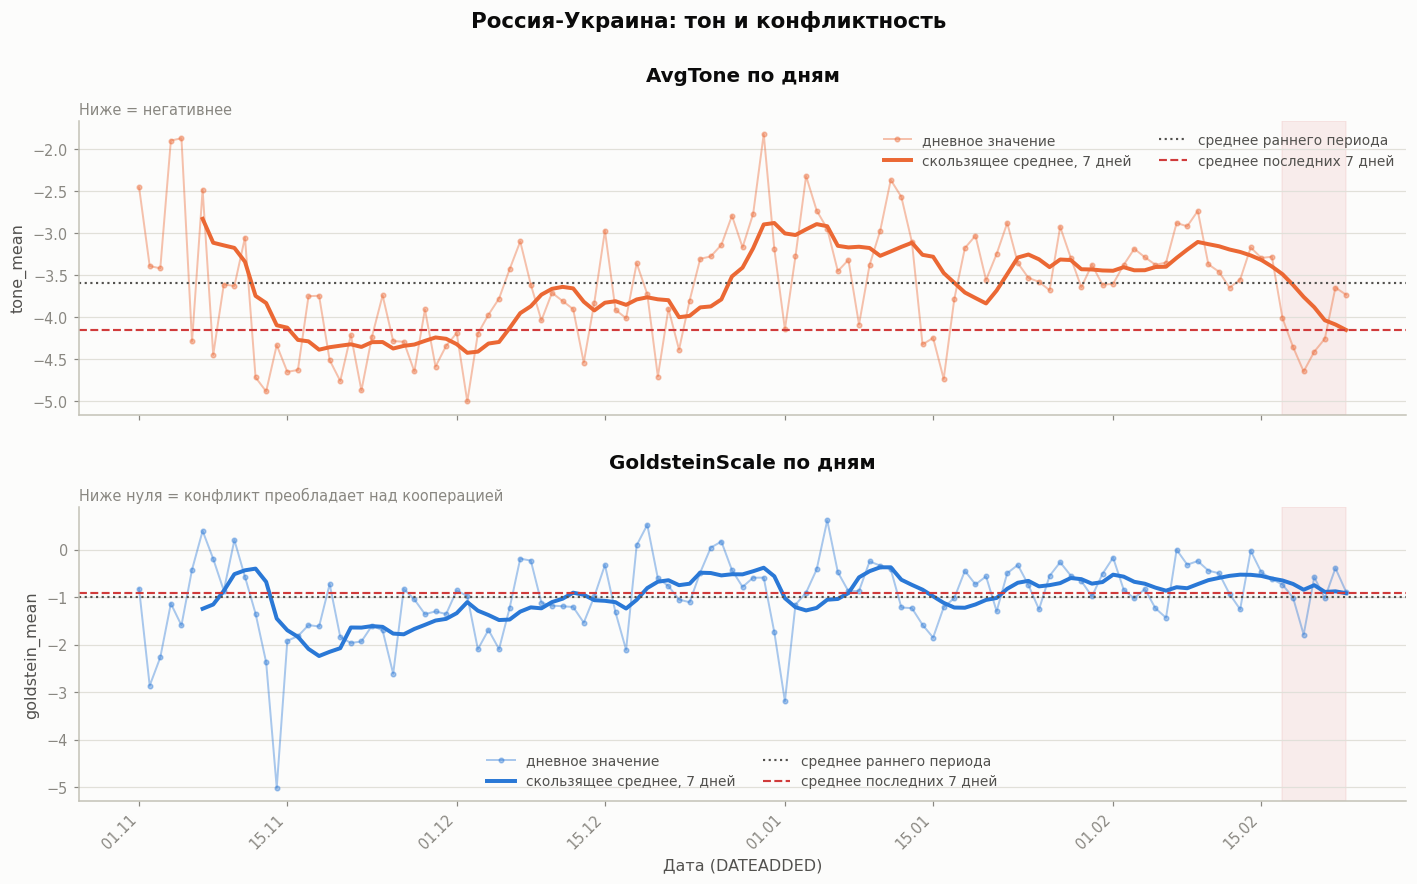

In [36]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for ax, (col, roll, human, sub, color) in zip(axes, [
        ("tone_mean", "roll7_tone_mean", "AvgTone по дням", "Ниже = негативнее", ORANGE),
        ("goldstein_mean", "roll7_goldstein_mean", "GoldsteinScale по дням",
         "Ниже нуля = конфликт преобладает над кооперацией", BLUE)]):
    ax.plot(daily.index, daily[col], color=color, alpha=0.40, lw=1.3, marker="o", markersize=3,
            label="дневное значение")
    ax.plot(daily.index, daily[roll], color=color, lw=2.6, label="скользящее среднее, 7 дней")
    ax.axhline(daily.loc[daily.period == "early", col].mean(), color=INK_2, ls=":", lw=1.4,
               label="среднее раннего периода")
    ax.axhline(daily.loc[daily.period == "late", col].mean(), color=CRITICAL, ls="--", lw=1.4,
               label="среднее последних 7 дней")
    ax.axvspan(SPLIT, daily.index.max(), color=CRITICAL, alpha=0.08)
    ax.set_title(human); subtitle(ax, sub); ax.set_ylabel(col)
    ax.legend(ncol=2, fontsize=9, loc="best")
axes[1].set_xlabel("Дата (DATEADDED)")
axes[1].xaxis.set_major_formatter(DateFormatter("%d.%m"))
fig.suptitle(f"{CASE_NAME}: тон и конфликтность", fontsize=14, fontweight="bold", color=INK, y=1.0)
fig.autofmt_xdate(rotation=45, ha="right"); plt.tight_layout(h_pad=2.0); plt.show()

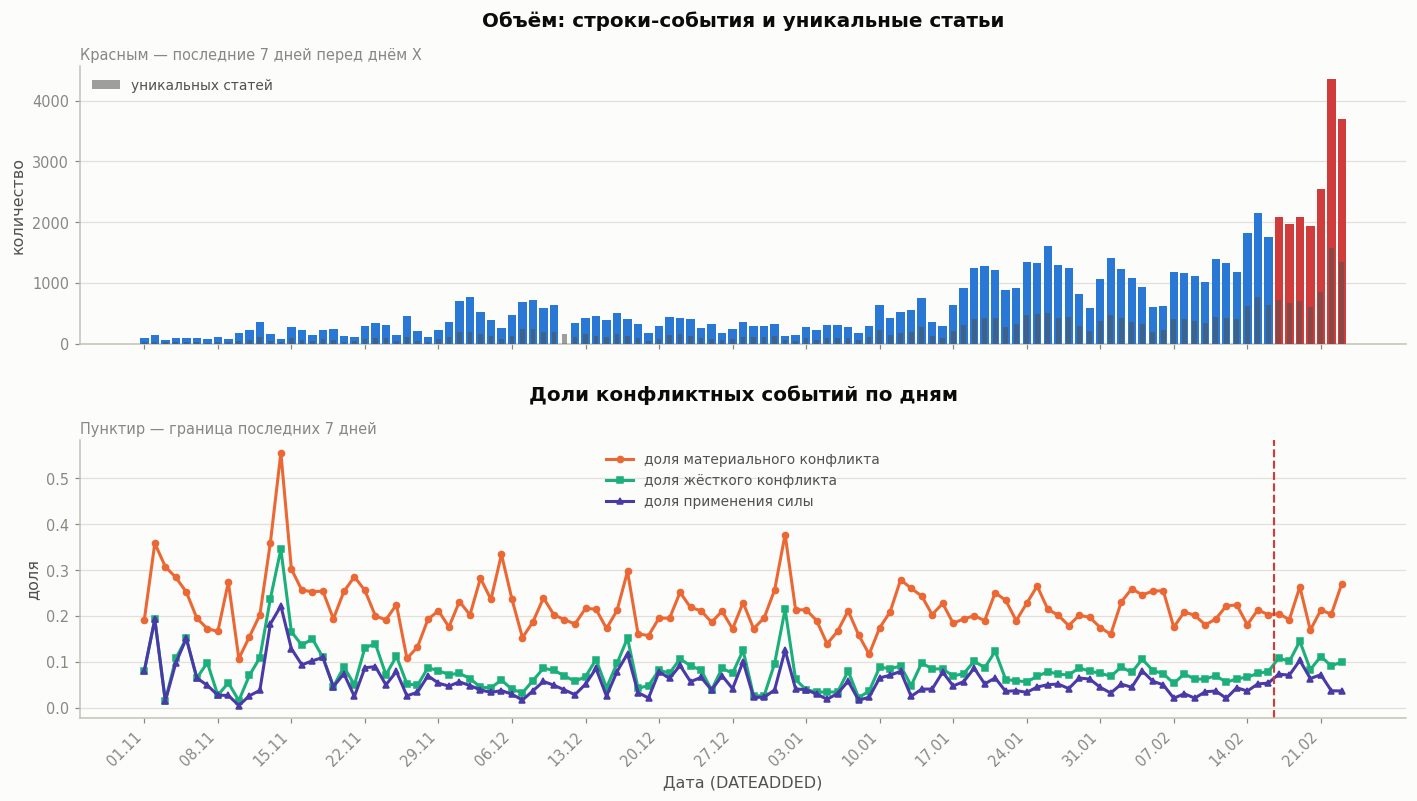

In [37]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7.4), sharex=True)
xs = np.arange(len(daily)); late_mask = np.asarray(daily.period == "late")
ax1.bar(xs, daily.n_events, color=[CRITICAL if l else BLUE for l in late_mask], zorder=3)
ax1.bar(xs, daily.unique_urls, color=INK_2, alpha=0.55, width=0.45, zorder=4,
        label="уникальных статей")
ax1.set_title("Объём: строки-события и уникальные статьи")
subtitle(ax1, "Красным — последние 7 дней перед днём X")
ax1.set_ylabel("количество"); ax1.legend(loc="upper left", fontsize=9)

ax2.plot(xs, daily.material_conflict_share, color=ORANGE, lw=2, marker="o", markersize=4,
         label="доля материального конфликта")
ax2.plot(xs, daily.conflict_hard_share, color=AQUA, lw=2, marker="s", markersize=4,
         label="доля жёсткого конфликта")
ax2.plot(xs, daily.force_use_share, color="#4a3aa7", lw=2, marker="^", markersize=4,
         label="доля применения силы")
ax2.axvline(len(daily) - 7.5, color=CRITICAL, ls="--", lw=1.4)
ax2.set_title("Доли конфликтных событий по дням")
subtitle(ax2, "Пунктир — граница последних 7 дней")
ax2.set_ylabel("доля"); ax2.set_xlabel("Дата (DATEADDED)"); ax2.legend(fontsize=9)
step = max(1, len(daily)//15)
ax2.set_xticks(xs[::step]); ax2.set_xticklabels([d.strftime("%d.%m") for d in daily.index[::step]],
                                                rotation=45, ha="right")
plt.tight_layout(h_pad=2.0); plt.show()

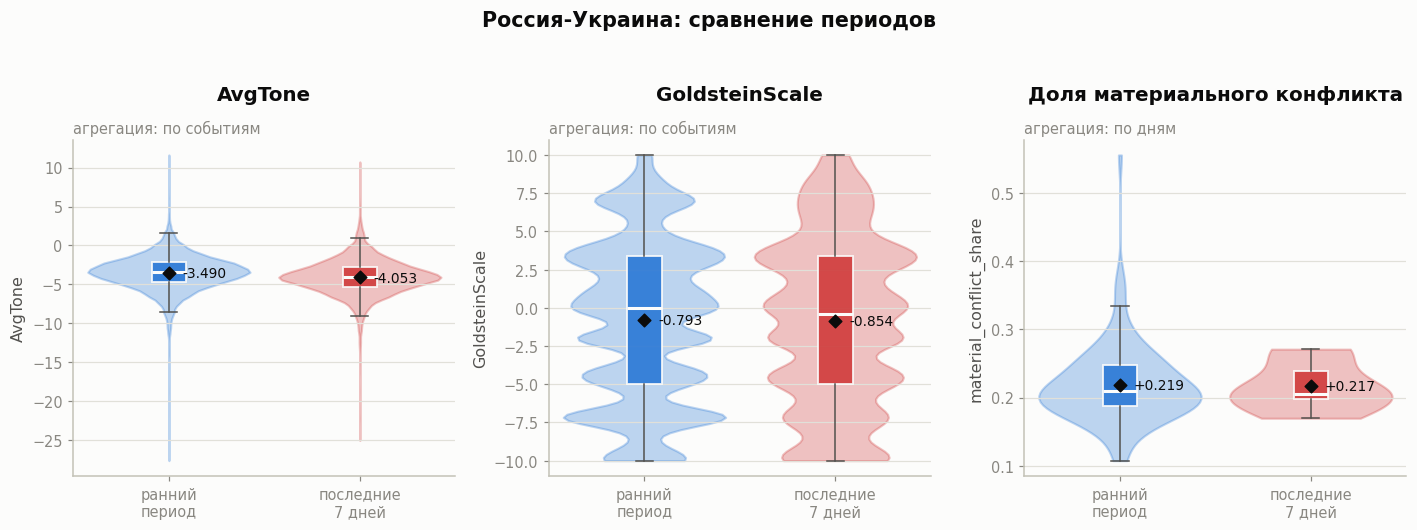

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
for ax, (col, source, human, level) in zip(axes, [
        ("AvgTone", df, "AvgTone", "по событиям"),
        ("GoldsteinScale", df, "GoldsteinScale", "по событиям"),
        ("material_conflict_share", daily, "Доля материального конфликта", "по дням")]):
    data = [source.loc[source.period == "early", col].dropna().values,
            source.loc[source.period == "late", col].dropna().values]
    vp = ax.violinplot(data, showextrema=False, widths=0.85)
    for body, c in zip(vp["bodies"], [BLUE, CRITICAL]):
        body.set(facecolor=c, alpha=0.30, edgecolor=c, linewidth=1.4)
    bp = ax.boxplot(data, widths=0.18, patch_artist=True, showfliers=False)
    for box, c in zip(bp["boxes"], [BLUE, CRITICAL]):
        box.set(facecolor=c, alpha=0.9, edgecolor=SURFACE, linewidth=1.2)
    for el in ("whiskers", "caps"): [ln.set(color=INK_2, lw=1.0) for ln in bp[el]]
    for med in bp["medians"]: med.set(color=SURFACE, lw=2.0)
    for i, arr in enumerate(data, start=1):
        ax.scatter([i], [arr.mean()], color=INK, s=34, zorder=5, marker="D")
        ax.annotate(f"{arr.mean():+.3f}", xy=(i, arr.mean()), xytext=(9, -3),
                    textcoords="offset points", fontsize=9, color=INK)
    ax.set_xticks([1, 2]); ax.set_xticklabels(["ранний\nпериод", "последние\n7 дней"])
    ax.set_title(human); subtitle(ax, f"агрегация: {level}"); ax.set_ylabel(col)
fig.suptitle(f"{CASE_NAME}: сравнение периодов", fontsize=13.5, fontweight="bold", color=INK, y=1.04)
plt.tight_layout(); plt.show()

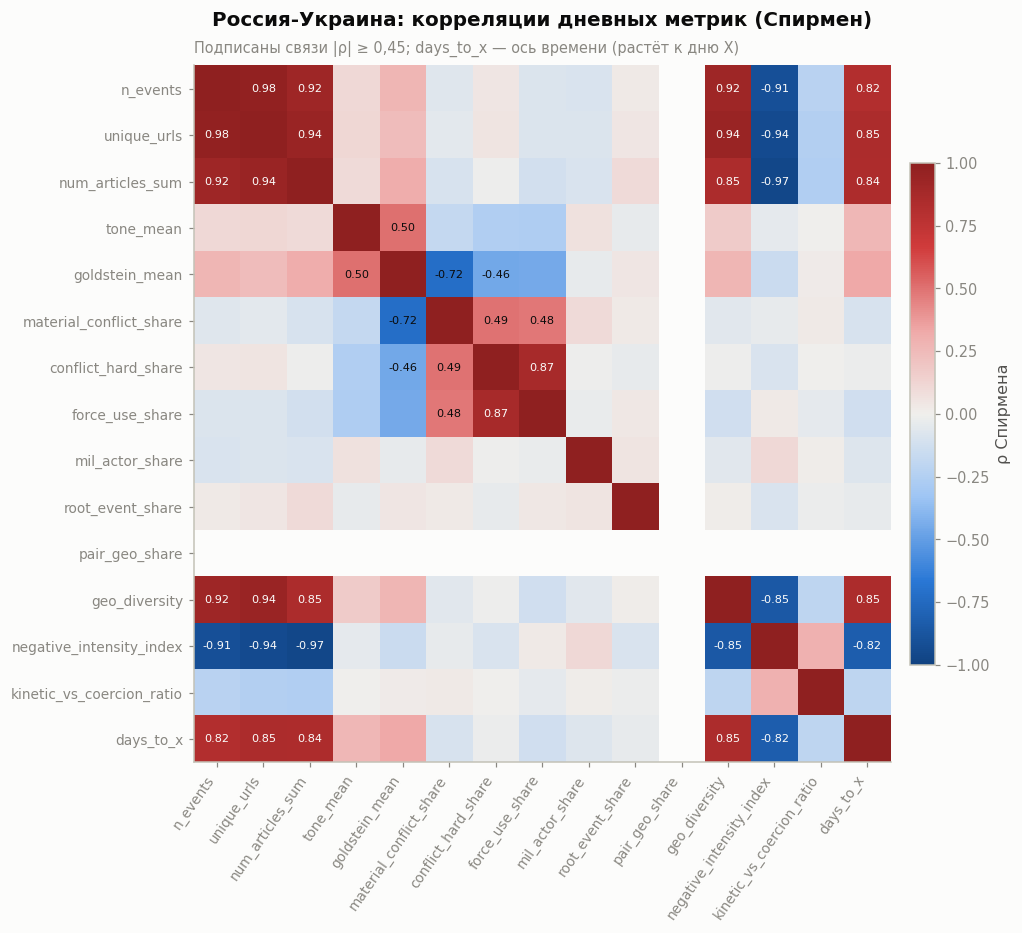

Связь метрик со временем (days_to_x; положительная = растёт к дню X):


,ρ
negative_intensity_index,-0.8230
kinetic_vs_coercion_ratio,-0.1980
force_use_share,-0.1310
material_conflict_share,-0.0970
mil_actor_share,-0.0720
root_event_share,-0.0360
conflict_hard_share,-0.0210
tone_mean,0.2610
goldstein_mean,0.3320
n_events,0.8180


In [39]:
corr_cols = ["n_events", "unique_urls", "num_articles_sum", "tone_mean", "goldstein_mean",
             "material_conflict_share", "conflict_hard_share", "force_use_share",
             "mil_actor_share", "root_event_share", "pair_geo_share", "geo_diversity",
             "negative_intensity_index", "kinetic_vs_coercion_ratio", "days_to_x"]
C = daily[corr_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(10.5, 8.6))
im = ax.imshow(C.values, cmap=DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=55, ha="right", fontsize=9)
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols, fontsize=9)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        v = C.values[i, j]
        if i != j and abs(v) >= 0.45:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.4,
                    color=SURFACE if abs(v) > 0.72 else INK)
ax.set_title(f"{CASE_NAME}: корреляции дневных метрик (Спирмен)")
subtitle(ax, "Подписаны связи |ρ| ≥ 0,45; days_to_x — ось времени (растёт к дню X)")
ax.grid(False)
cb = fig.colorbar(im, ax=ax, shrink=0.72, pad=0.02); cb.set_label("ρ Спирмена", color=INK_2)
plt.tight_layout(); plt.show()
print("Связь метрик со временем (days_to_x; положительная = растёт к дню X):")
display(C["days_to_x"].drop("days_to_x").sort_values().to_frame("ρ").round(3))

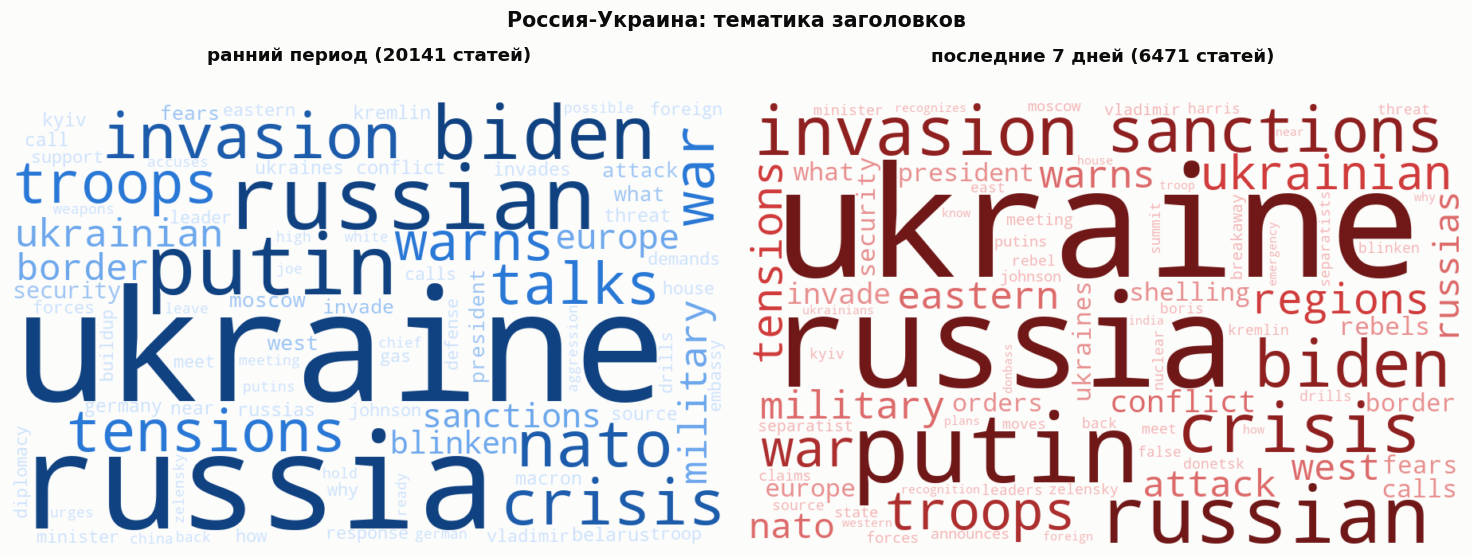

Лексика (по уникальным статьям): ранний — кинетика 202, принуждение 606 -> доля 0.250
                                поздний — кинетика 92, принуждение 532 -> доля 0.147


In [40]:
uniq2 = df.drop_duplicates(subset="SOURCEURL").copy()
counts = {}
for lab, sub in [("ранний период", uniq2[uniq2.date_added < SPLIT]),
                 ("последние 7 дней", uniq2[uniq2.date_added >= SPLIT])]:
    counts[lab] = Counter(w for ws in sub.slug_words for w in ws)

def ramp_color(ramp):
    def f(word, font_size, position, orientation, random_state=None, **kw):
        idx = int(np.clip((font_size - 12)/78*(len(ramp)-1), 0, len(ramp)-1))
        return ramp[idx]
    return f
RAMPS = {"ранний период": SEQ_BLUE,
         "последние 7 дней": ["#f3b5b5", "#e88f8f", "#dd6a6a", "#d03b3b", "#ad2e2e", "#8f2020", "#701818"]}

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
for ax, lab in zip(axes, ["ранний период", "последние 7 дней"]):
    if sum(counts[lab].values()) == 0:
        ax.axis("off"); ax.set_title(f"{lab}: слов не найдено"); continue
    wc = WordCloud(width=900, height=560, background_color=SURFACE, prefer_horizontal=0.95,
                   max_words=80, relative_scaling=0.5, random_state=7,
                   color_func=ramp_color(RAMPS[lab]), margin=4).generate_from_frequencies(counts[lab])
    ax.imshow(wc, interpolation="bilinear"); ax.axis("off")
    n_art = len(uniq2[uniq2.date_added < SPLIT]) if lab == "ранний период" else len(uniq2[uniq2.date_added >= SPLIT])
    ax.set_title(f"{lab} ({n_art} статей)", fontsize=12)
fig.suptitle(f"{CASE_NAME}: тематика заголовков", fontsize=13.5, fontweight="bold", color=INK, y=1.03)
plt.tight_layout(); plt.show()

k_e = int(uniq2.loc[uniq2.date_added < SPLIT, "kinetic_hits"].sum())
c_e = int(uniq2.loc[uniq2.date_added < SPLIT, "coercion_hits"].sum())
k_l = int(uniq2.loc[uniq2.date_added >= SPLIT, "kinetic_hits"].sum())
c_l = int(uniq2.loc[uniq2.date_added >= SPLIT, "coercion_hits"].sum())
print(f"Лексика (по уникальным статьям): ранний — кинетика {k_e}, принуждение {c_e}"
      f"{f' -> доля {k_e/(k_e+c_e):.3f}' if k_e+c_e else ' -> слов нет'}")
print(f"                                поздний — кинетика {k_l}, принуждение {c_l}"
      f"{f' -> доля {k_l/(k_l+c_l):.3f}' if k_l+c_l else ' -> слов нет'}")

**Вывод по разделу 6.** Главное, что показывают графики, — разная форма двух сигналов.

**Объём** нарастает плавно и монотонно всё окно: корреляция со временем ρ = +0,82 для числа
событий, +0,85 для уникальных статей и географического разброса. Ни в одном другом кейсе серии
такого ровного разгона нет — там объём скакал вместе с отдельными новостями.

**Тон и конфликтность** ведут себя иначе: почти всё окно они колеблются вокруг своих средних
(и даже слегка улучшаются, см. гипотезу C), а затем обваливаются в последние дни. На панели долей
конфликтных событий это видно как резкий подъём оранжевой и бирюзовой линий после 16 февраля.

Облака слов подтверждают лексический результат: доля «кинетических» слов упала с 0,250 до 0,147 —
в заголовках последней недели доминируют санкции, переговоры и дипломатия, а не удары.

---
## 7. Правило TONE-1σ

Правило зафиксировано на тренировочной выборке из пяти кейсов и здесь применяется **без
изменений**: тревога, если средний `AvgTone` последних 7 дней ниже фона предыдущих четырёх недель
на одну сигму и более.

окно оценки: 2022-02-17 — 2022-02-23
  тон окна: -4.151 | фон 4 недель: -3.327 ± 0.149
  z_tone = +5.544 при пороге +1.0  ->  ТРЕВОГА

в режиме мониторинга: 7 срабатываний из 81 окон (8.6 %), эпизодов: 3
   2022-01-20 — 2022-01-20 (макс z = +1.15)
   2022-01-30 — 2022-01-30 (макс z = +1.01)
   2022-02-19 — 2022-02-23 (макс z = +8.20)


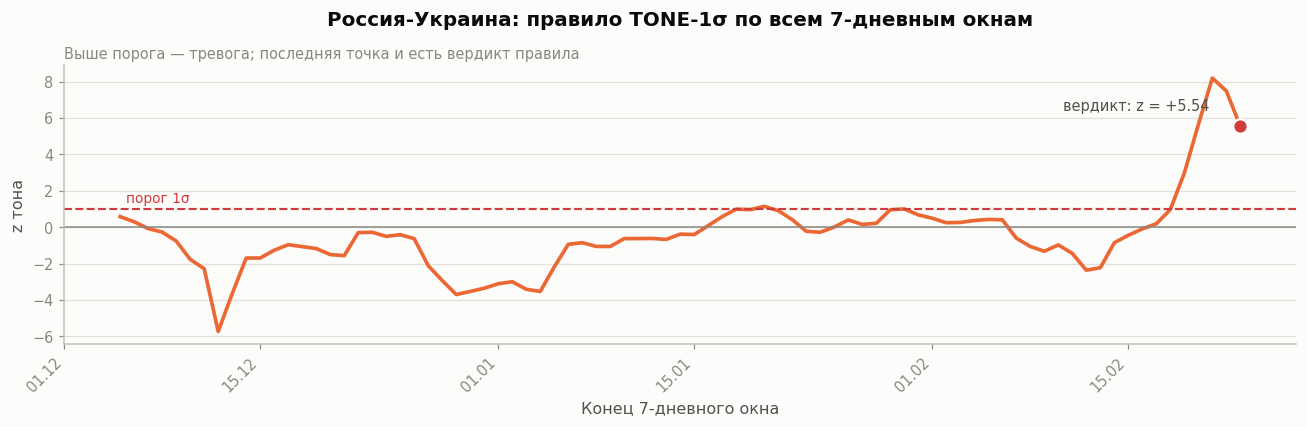

In [41]:
# ЗАФИКСИРОВАННОЕ ПРАВИЛО TONE-1σ (обучено на пяти кейсах, здесь применяется без изменений)
BASE_WEEKS, THRESHOLD = 4, 1.0
need = 7 + BASE_WEEKS*7
window_tone = daily.tone_mean.iloc[-7:].mean()
base = daily.tone_mean.iloc[-need:-7]
blocks = np.array([base.iloc[i:i+7].mean() for i in range(0, len(base)-6, 7)])
z_tone = -(window_tone - blocks.mean()) / blocks.std(ddof=1)

print(f"окно оценки: {daily.index[-7].date()} — {daily.index[-1].date()}")
print(f"  тон окна: {window_tone:+.3f} | фон 4 недель: {blocks.mean():+.3f} ± {blocks.std(ddof=1):.3f}")
print(f"  z_tone = {z_tone:+.3f} при пороге {THRESHOLD:+.1f}  ->  "
      f"{'ТРЕВОГА' if z_tone >= THRESHOLD else 'НЕТ СИГНАЛА'}")

# То же правило в режиме ежедневного мониторинга — сколько раз оно сработало бы за окно
def window_z(end):
    w = daily.tone_mean.iloc[end-7:end]; b = daily.tone_mean.iloc[max(0, end-need):end-7]
    bl = [b.iloc[i:i+7].mean() for i in range(0, len(b)-6, 7)]
    if len(bl) < 3: return None
    bl = np.array(bl)
    return -(w.mean() - bl.mean())/bl.std(ddof=1)
zs = [(daily.index[e-1], window_z(e)) for e in range(need, len(daily)+1) if window_z(e) is not None]
MON = pd.DataFrame(zs, columns=["конец_окна", "z_tone"]).set_index("конец_окна")
MON["тревога"] = MON.z_tone >= THRESHOLD
eps, start = [], None
for i, v in enumerate(MON.тревога.values):
    if v and start is None: start = i
    if not v and start is not None: eps.append((start, i-1)); start = None
if start is not None: eps.append((start, len(MON)-1))
print(f"\nв режиме мониторинга: {int(MON.тревога.sum())} срабатываний из {len(MON)} окон "
      f"({MON.тревога.mean()*100:.1f} %), эпизодов: {len(eps)}")
for a, b_ in eps:
    print(f"   {MON.index[a].date()} — {MON.index[b_].date()} (макс z = {MON.z_tone.iloc[a:b_+1].max():+.2f})")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(MON.index, MON.z_tone, color=ORANGE, lw=2.4)
ax.axhline(THRESHOLD, color=CRITICAL, ls="--", lw=1.4)
ax.annotate("порог 1σ", xy=(MON.index[0], THRESHOLD), xytext=(4, 4), textcoords="offset points",
            color=CRITICAL, fontsize=9)
ax.axhline(0, color=MUTED, lw=1.0)
ax.scatter([MON.index[-1]], [MON.z_tone.iloc[-1]], color=CRITICAL if z_tone >= THRESHOLD else INK_2,
           s=90, zorder=5, edgecolor=SURFACE, lw=1.5)
ax.annotate(f"вердикт: z = {z_tone:+.2f}", xy=(MON.index[-1], MON.z_tone.iloc[-1]),
            xytext=(-116, 10), textcoords="offset points", fontsize=9.5, color=INK_2)
ax.set_title(f"{CASE_NAME}: правило TONE-1σ по всем 7-дневным окнам")
subtitle(ax, "Выше порога — тревога; последняя точка и есть вердикт правила")
ax.set_ylabel("z тона"); ax.set_xlabel("Конец 7-дневного окна")
ax.xaxis.set_major_formatter(DateFormatter("%d.%m"))
fig.autofmt_xdate(rotation=45, ha="right"); plt.tight_layout(); plt.show()

**Вывод по разделу 7 — это лучший результат правила во всей серии.**

`z_tone = +5,544` при пороге 1,0. Тон последней недели (−4,151) отстоит от фона предыдущих
четырёх недель (−3,327) на пять с половиной стандартных отклонений — фон здесь исключительно
стабилен (± 0,149), потому что данных много и они ровные.

Ещё важнее поведение в режиме ежедневного мониторинга:

| Кейс | Срабатываний | Эпизодов | Пик z |
|---|---|---|---|
| **Россия — Украина** | **8,6 % окон** | 3 | **+8,20** |
| Тайвань — КНР (отрицательный) | 19,2 % | 2 | +6,69 |
| Армения — Азербайджан | 23,1 % | 3 | — |
| Индия — Пакистан | 42,3 % | 1 | — |
| СА — Йемен | 50,0 % | 2 | — |

**Самая низкая частота срабатывания и самый высокий пик одновременно.** Два ложных эпизода
(20 и 30 января, z = 1,15 и 1,01) едва переваливают порог, а настоящий сигнал 19–23 февраля
достигает z = 8,20 — то есть отделён от шума с огромным запасом. Это именно то соотношение
сигнала и фона, которого не хватало в остальных кейсах.

## 8. Выводы

### Итог по кейсу

| Гипотеза | Результат |
|---|---|
| A — сдвиг тона | **подтвердилась**: d = −0,250, p < 10⁻⁶, держится при кластерах и на уровне статьи |
| B — рост долей конфликта | **подтвердилась**: жёсткий конфликт 7,6 % → 10,4 %, единственный случай в серии, переживший все проверки |
| C — тренд | **не подтвердилась**: значимые тренды направлены против гипотезы |
| Правило TONE-1σ | **тревога**, z = +5,54 при 8,6 % ложных срабатываний — лучший результат серии |

**Чем этот кейс отличается от остальных.** Здесь впервые совпало три вещи: много данных
(79 тысяч событий, 26 тысяч статей), чистая структура (ни одного дня с доминированием статьи в
позднем периоде) и стабильный фон (± 0,149 у тона против ± 1,53 у Индии — Пакистана). В таких
условиях правило работает так, как задумывалось: сигнал в пять с половиной сигм против двух
пограничных ложных тревог за четыре месяца.

**Что подтвердилось из общих выводов серии:**

- тон остаётся самым надёжным индикатором;
- доля **материального** конфликта снова оказалась пустой метрикой: значима на уровне событий,
  разваливается при учёте зависимости наблюдений;
- линейный тренд на длинном окне сигнал не ловит — обвал сконцентрирован в последней неделе;
- лексическая метрика опять не сработала: доля «ударных» слов **упала** перед вторжением.

**Что нового:**

- **доля жёсткого конфликта** (коды 18/19/20) впервые прошла все проверки устойчивости. В серии
  из пяти обучающих кейсов она работала только у Индии — Пакистана, и то без проверки на уровне
  статьи. Это повод пересмотреть её как кандидата в предикторы — но проверять нужно на новых
  данных, а не на этом кейсе;
- **объём** растёт монотонно (ρ ≈ 0,82–0,85 со временем), а не скачком. Если такая форма
  повторится на других кейсах, «плавный разгон объёма» может оказаться отдельным признаком,
  отличающим подготовку вторжения от одиночного инцидента.

### Ограничения

1. **Окно длиннее остальных** — 115 дней против 58–63. Это делает фон устойчивее и облегчает
   срабатывание правила; сравнивать частоту ложных тревог с другими кейсами нужно с оговоркой.
2. **Метрика географии не работает** (коды акторов вместо FIPS), поэтому один из двенадцати
   тестов пуст, а поправка Бонферрони формально чуть строже, чем нужно.
3. **Ячейки не перевыполнялись**: выводы написаны по выводу прогона, сделанного на локальной
   копии данных. Файл CSV в репозиторий не входит.
4. **n = 1.** Как и в остальных кейсах серии, один случай ничего не доказывает: он лишь
   показывает, как индикаторы ведут себя, когда данных много и они чистые.